# Report figures

This notebook creates the figures used in the report. It reads only the raw FOMC file.

In [1]:
import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomc_nlp_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import normalize
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "fomc_documents_raw.csv").exists():
    ROOT = ROOT.parent

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

raw = pd.read_csv(ROOT / "data" / "raw" / "fomc_documents_raw.csv", parse_dates=["date"])
raw.shape

(199, 9)

In [2]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)


def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace(" ", " ")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def count_words(text):
    return len(TOKEN_RE.findall(clean_text(text)))


RATE_PATTERNS = {
    "hike": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(raise|raising|increase|increasing)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(raise|raising|increase|increasing|increased)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "cut": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "hold": [
        r"\b(decided|voted|agreed)\b.{0,80}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(will|would|shall|to)\b.{0,20}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(maintain|maintaining|keep|keeping|kept|leave|leaving)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(target range|target for the federal funds rate|federal funds rate)\b.{0,80}\b(unchanged|maintained)\b",
    ],
}


def infer_rate_decision(text):
    text = clean_text(text)
    for label in ["hike", "cut", "hold"]:
        if any(re.search(pattern, text, flags=re.DOTALL) for pattern in RATE_PATTERNS[label]):
            return label
    return "unknown"


def period_label(date):
    date = pd.Timestamp(date)
    if pd.Timestamp("2001-03-01") <= date <= pd.Timestamp("2001-11-30"):
        return "2001 recession"
    if pd.Timestamp("2007-12-01") <= date <= pd.Timestamp("2009-06-30"):
        return "GFC"
    if pd.Timestamp("2020-02-01") <= date <= pd.Timestamp("2020-06-30"):
        return "Covid shock"
    if pd.Timestamp("2021-01-01") <= date <= pd.Timestamp("2024-12-31"):
        return "post-Covid inflation"
    return "other"


PERIOD_ORDER = ["2001 recession", "GFC", "Covid shock", "post-Covid inflation", "other"]


df = (
    raw.sort_values("date")
    .reset_index(drop=True)
    .assign(
        statement_clean_text=lambda x: x["statement_text"].map(clean_text),
        minutes_clean_text=lambda x: x["minutes_text"].map(clean_text),
        statement_n_words=lambda x: x["statement_text"].map(count_words),
        minutes_n_words=lambda x: x["minutes_text"].map(count_words),
        rate_decision=lambda x: x["statement_text"].map(infer_rate_decision),
        period=lambda x: x["date"].map(period_label),
    )
    .assign(
        next_rate_decision=lambda x: x["rate_decision"].shift(-1),
        period=lambda x: pd.Categorical(x["period"], categories=PERIOD_ORDER, ordered=True),
    )
)

df[["date", "statement_n_words", "minutes_n_words", "rate_decision"]].head()

,date,statement_n_words,minutes_n_words,rate_decision
0,2000-02-02,202,8319,hike
1,2000-03-21,208,4434,hike
2,2000-05-16,202,4072,hike
3,2000-06-28,178,4345,hold
4,2000-08-22,181,4208,hold


In [3]:
INFLATION_TERMS = [
    "inflation", "inflationary", "price stability", "price pressures",
    "inflation expectations", "core inflation", "pce inflation", "consumer prices",
    "energy prices", "food prices", "cost pressures", "supply constraints", "disinflation",
]

LABOR_TERMS = [
    "employment", "unemployment", "labor market", "job gains", "payrolls",
    "hiring", "layoffs", "wages", "labor demand", "labor supply",
    "labor force", "slack", "participation", "vacancies", "job openings",
]

DOCUMENT_LABELS = {"statement": "Statements", "minutes": "Minutes"}


def count_term_occurrences(text, term):
    text = clean_text(text)
    pattern = re.escape(term.lower()).replace(r"\ ", r"\s+")
    return len(re.findall(rf"\b{pattern}\b", text))


def count_terms(text, terms):
    return sum(count_term_occurrences(text, term) for term in terms)


def add_topic_score(data, corpus, topic, terms):
    text_col = f"{corpus}_clean_text"
    n_col = f"{corpus}_n_words"
    count_col = f"{corpus}_{topic}_count"
    freq_col = f"{corpus}_{topic}_per_1000"
    counts = data[text_col].map(lambda text: count_terms(text, terms))
    return data.assign(**{
        count_col: counts,
        freq_col: lambda x: 1_000 * x[count_col] / x[n_col].replace(0, np.nan),
    })


df = (
    df.pipe(add_topic_score, "statement", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "statement", "labor", LABOR_TERMS)
    .pipe(add_topic_score, "minutes", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "minutes", "labor", LABOR_TERMS)
    .assign(
        statement_balance=lambda x: x["statement_inflation_per_1000"] - x["statement_labor_per_1000"],
        minutes_balance=lambda x: x["minutes_inflation_per_1000"] - x["minutes_labor_per_1000"],
    )
    .assign(minutes_minus_statement_balance=lambda x: x["minutes_balance"] - x["statement_balance"])
)

summary = pd.DataFrame({
    "document_type": ["Statements", "Minutes"],
    "documents": [len(df), len(df)],
    "mean_words": [df["statement_n_words"].mean(), df["minutes_n_words"].mean()],
    "median_words": [df["statement_n_words"].median(), df["minutes_n_words"].median()],
    "mean_inflation": [df["statement_inflation_per_1000"].mean(), df["minutes_inflation_per_1000"].mean()],
    "mean_labor": [df["statement_labor_per_1000"].mean(), df["minutes_labor_per_1000"].mean()],
    "mean_balance": [df["statement_balance"].mean(), df["minutes_balance"].mean()],
})
summary.round(2)

,document_type,documents,mean_words,median_words,mean_inflation,mean_labor,mean_balance
0,Statements,199,526.14,536.0,18.37,7.75,10.62
1,Minutes,199,7283.18,7536.0,10.58,5.98,4.60


In [4]:
term_audit_rows = []
for corpus, document_type in DOCUMENT_LABELS.items():
    for topic, terms in {"inflation": INFLATION_TERMS, "labor": LABOR_TERMS}.items():
        text_col = f"{corpus}_clean_text"
        for term in terms:
            count = df[text_col].map(lambda text, term=term: count_term_occurrences(text, term)).sum()
            term_audit_rows.append({
                "document_type": document_type,
                "topic": topic,
                "term": term,
                "count": int(count),
            })

term_audit = pd.DataFrame(term_audit_rows)
top_term_audit = (
    term_audit
    .sort_values(["document_type", "topic", "count"], ascending=[True, True, False])
    .groupby(["document_type", "topic"], as_index=False, observed=True)
    .head(5)
)

top_term_audit

,document_type,topic,term,count
28,Minutes,inflation,inflation,10387
32,Minutes,inflation,inflation expectations,1587
36,Minutes,inflation,energy prices,985
30,Minutes,inflation,price stability,779
33,Minutes,inflation,core inflation,410
41,Minutes,labor,employment,2293
43,Minutes,labor,labor market,2235
42,Minutes,labor,unemployment,1953
53,Minutes,labor,participation,444
52,Minutes,labor,slack,442


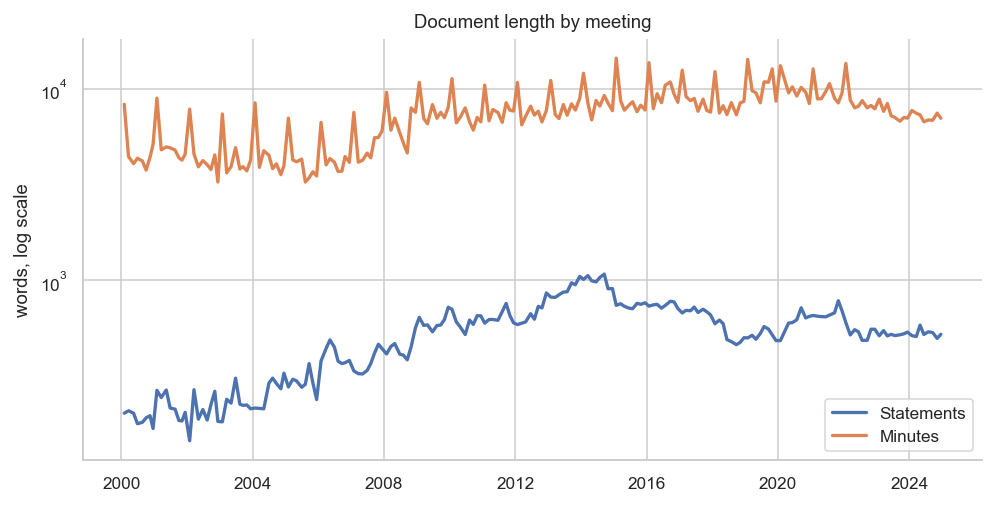

In [5]:
lengths = pd.concat([
    df.loc[:, ["date", "year", "statement_n_words"]]
    .rename(columns={"statement_n_words": "n_words"})
    .assign(document_type="Statements"),
    df.loc[:, ["date", "year", "minutes_n_words"]]
    .rename(columns={"minutes_n_words": "n_words"})
    .assign(document_type="Minutes"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(7.2, 3.7))
sns.lineplot(data=lengths, x="date", y="n_words", hue="document_type", ax=ax, linewidth=1.7)
ax.set_yscale("log")
ax.set_title("Document length by meeting")
ax.set_xlabel("")
ax.set_ylabel("words, log scale")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURES / "document_length_by_type.png", bbox_inches="tight")

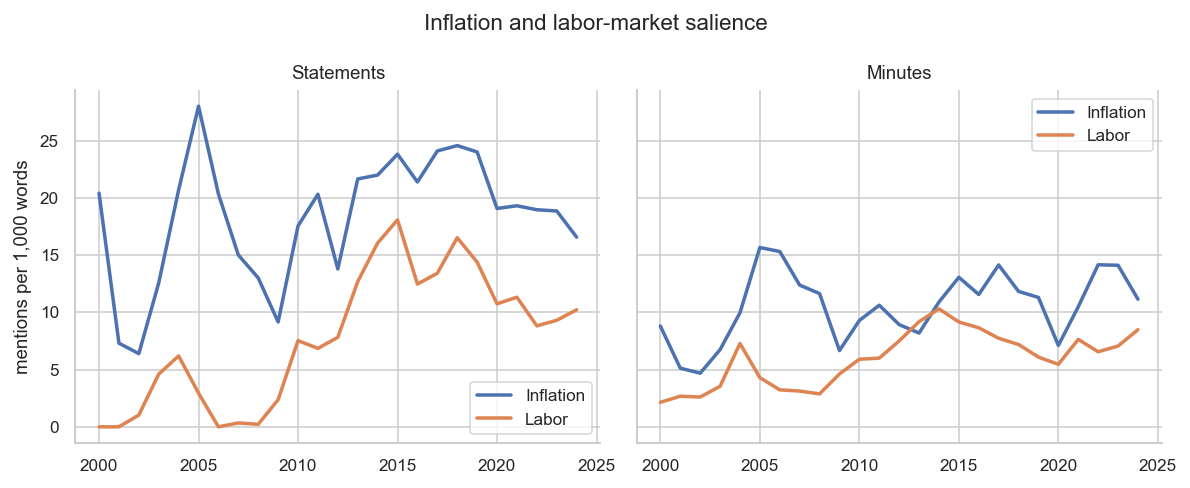

In [6]:
topic_long = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "next_rate_decision",
        "statement_inflation_per_1000", "statement_labor_per_1000",
        "minutes_inflation_per_1000", "minutes_labor_per_1000",
    ]]
    .melt(
        id_vars=["date", "year", "period", "rate_decision", "next_rate_decision"],
        var_name="measure",
        value_name="mentions_per_1000",
    )
    .assign(
        corpus=lambda x: x["measure"].str.extract(r"^(statement|minutes)")[0],
        topic=lambda x: x["measure"].str.extract(r"_(inflation|labor)_")[0].str.title(),
    )
    .assign(document_type=lambda x: x["corpus"].map(DOCUMENT_LABELS))
    .drop(columns=["measure", "corpus"])
)

yearly_topics = (
    topic_long
    .groupby(["year", "document_type", "topic"], observed=True, as_index=False)["mentions_per_1000"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.5), sharey=True)
for ax, document_type in zip(axes, ["Statements", "Minutes"]):
    plot_data = yearly_topics.loc[yearly_topics["document_type"].eq(document_type)]
    sns.lineplot(data=plot_data, x="year", y="mentions_per_1000", hue="topic", ax=ax, linewidth=1.8)
    ax.set_title(document_type)
    ax.set_xlabel("")
    ax.set_ylabel("mentions per 1,000 words" if ax is axes[0] else "")
    ax.legend(title="")
fig.suptitle("Inflation and labor-market salience")
fig.tight_layout()
fig.savefig(FIGURES / "mandate_salience_over_time.png", bbox_inches="tight")

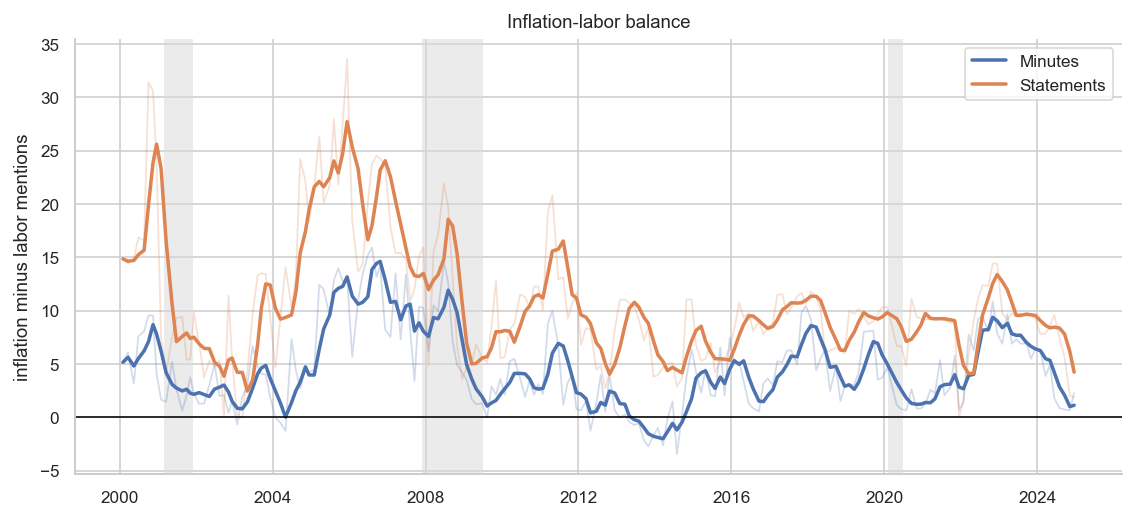

In [7]:
balance_long = (
    df.loc[:, ["date", "year", "period", "rate_decision", "next_rate_decision", "statement_balance", "minutes_balance"]]
    .melt(
        id_vars=["date", "year", "period", "rate_decision", "next_rate_decision"],
        value_vars=["statement_balance", "minutes_balance"],
        var_name="document_type",
        value_name="balance_per_1000",
    )
    .assign(
        corpus=lambda x: x["document_type"].str.replace("_balance", "", regex=False),
    )
    .assign(document_type=lambda x: x["corpus"].map(DOCUMENT_LABELS))
    .drop(columns="corpus")
)

balance_plot = (
    balance_long
    .sort_values(["document_type", "date"])
    .assign(
        rolling_balance=lambda x: (
            x.groupby("document_type", observed=True)["balance_per_1000"]
            .transform(lambda s: s.rolling(4, min_periods=1).mean())
        )
    )
)

fig, ax = plt.subplots(figsize=(8.2, 3.8))
for start, end, label in [
    ("2001-03-01", "2001-11-30", "2001"),
    ("2007-12-01", "2009-06-30", "GFC"),
    ("2020-02-01", "2020-06-30", "Covid"),
]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="0.85", alpha=0.5, linewidth=0)

sns.lineplot(
    data=balance_plot,
    x="date",
    y="balance_per_1000",
    hue="document_type",
    ax=ax,
    linewidth=0.9,
    alpha=0.25,
    legend=False,
)
sns.lineplot(
    data=balance_plot,
    x="date",
    y="rolling_balance",
    hue="document_type",
    ax=ax,
    linewidth=1.8,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation-labor balance")
ax.set_xlabel("")
ax.set_ylabel("inflation minus labor mentions")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURES / "mandate_balance_over_time.png", bbox_inches="tight")

,document_type,sentence_type,sentences,share,share_pct
1,Minutes,inflation only,6653,0.107,10.7
2,Minutes,labor only,4349,0.070,7.0
4,Minutes,both,2223,0.036,3.6
0,Minutes,neither,48849,0.787,78.7
5,Statements,inflation only,691,0.130,13.0
7,Statements,labor only,294,0.055,5.5
6,Statements,both,575,0.108,10.8
3,Statements,neither,3769,0.707,70.7


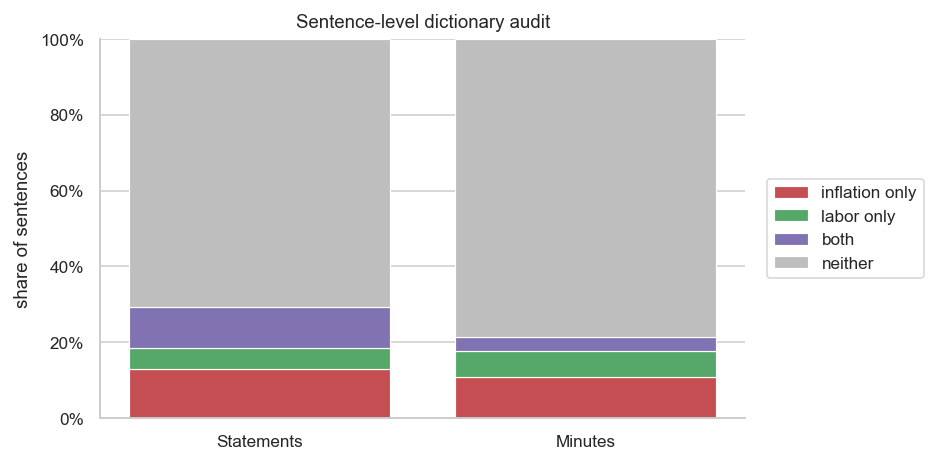

In [8]:
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")
SENTENCE_ORDER = ["inflation only", "labor only", "both", "neither"]


def sentence_bucket(sentence):
    has_inflation = count_terms(sentence, INFLATION_TERMS) > 0
    has_labor = count_terms(sentence, LABOR_TERMS) > 0
    if has_inflation and has_labor:
        return "both"
    if has_inflation:
        return "inflation only"
    if has_labor:
        return "labor only"
    return "neither"


sentence_rows = []
for corpus, document_type in DOCUMENT_LABELS.items():
    for text in df[f"{corpus}_clean_text"]:
        for sentence in SENTENCE_SPLIT_RE.split(text):
            sentence = sentence.strip()
            if sentence:
                sentence_rows.append({
                    "document_type": document_type,
                    "sentence_type": sentence_bucket(sentence),
                })

sentence_audit = pd.DataFrame(sentence_rows)
sentence_summary = (
    sentence_audit
    .value_counts(["document_type", "sentence_type"])
    .rename("sentences")
    .reset_index()
    .assign(
        sentence_type=lambda x: pd.Categorical(x["sentence_type"], categories=SENTENCE_ORDER, ordered=True),
        share=lambda x: x["sentences"] / x.groupby("document_type")["sentences"].transform("sum"),
    )
    .sort_values(["document_type", "sentence_type"])
)

sentence_plot = (
    sentence_summary
    .pivot(index="document_type", columns="sentence_type", values="share")
    .reindex(["Statements", "Minutes"])
    .fillna(0)
)

colors = {
    "inflation only": "#C44E52",
    "labor only": "#55A868",
    "both": "#8172B2",
    "neither": "#BEBEBE",
}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
bottom = np.zeros(len(sentence_plot))
for sentence_type in SENTENCE_ORDER:
    values = sentence_plot[sentence_type].to_numpy()
    ax.bar(
        sentence_plot.index,
        values,
        bottom=bottom,
        label=sentence_type,
        color=colors[sentence_type],
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += values
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title("Sentence-level dictionary audit")
ax.set_xlabel("")
ax.set_ylabel("share of sentences")
ax.legend(title="", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
fig.tight_layout()
fig.savefig(FIGURES / "sentence_topic_audit.png", bbox_inches="tight")

sentence_summary.assign(share_pct=lambda x: 100 * x["share"]).round({"share": 3, "share_pct": 1})

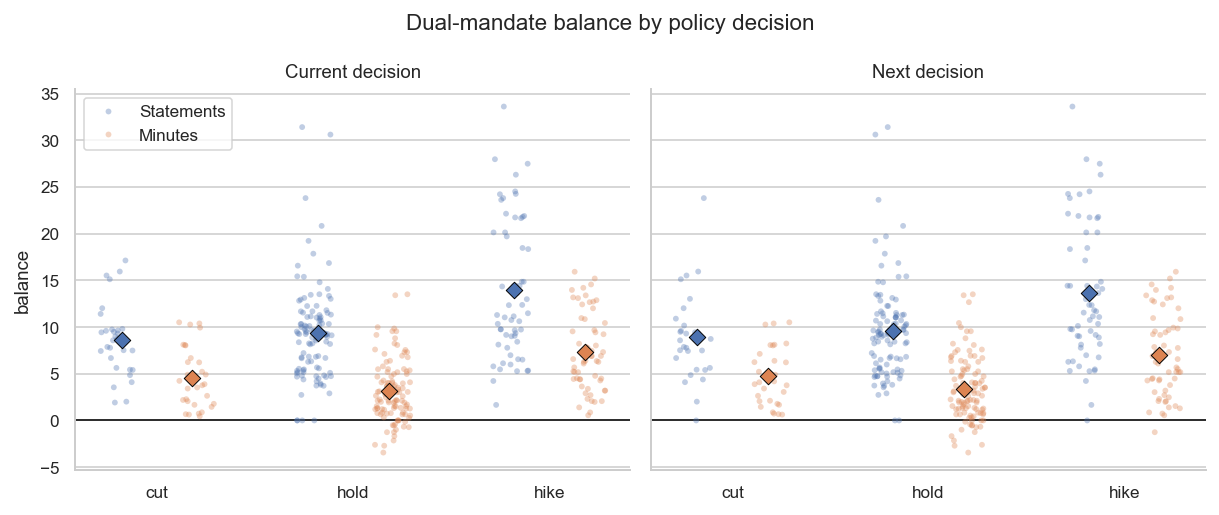

In [9]:
decision_order = ["cut", "hold", "hike"]
palette = {"Statements": "#4C72B0", "Minutes": "#DD8452"}
offsets = {"Statements": -0.18, "Minutes": 0.18}


def decision_stripplot(data, decision_col, ax, title, show_legend=False):
    sns.stripplot(
        data=data,
        x=decision_col,
        y="balance_per_1000",
        hue="document_type",
        order=decision_order,
        dodge=True,
        jitter=0.18,
        alpha=0.35,
        size=3,
        palette=palette,
        ax=ax,
    )
    for i, decision in enumerate(decision_order):
        for document_type, offset in offsets.items():
            values = data.loc[
                data[decision_col].eq(decision) & data["document_type"].eq(document_type),
                "balance_per_1000",
            ]
            if len(values):
                ax.scatter(
                    i + offset,
                    values.mean(),
                    marker="D",
                    s=36,
                    color=palette[document_type],
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("balance" if ax is axes[0] else "")
    if show_legend:
        ax.legend(title="", loc="upper left", frameon=True)
    elif ax.legend_ is not None:
        ax.legend_.remove()


fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.7), sharey=True)
decision_stripplot(balance_long, "rate_decision", axes[0], "Current decision", show_legend=True)
decision_stripplot(
    balance_long.dropna(subset=["next_rate_decision"]),
    "next_rate_decision",
    axes[1],
    "Next decision",
)
fig.suptitle("Dual-mandate balance by policy decision")
fig.tight_layout()
fig.savefig(FIGURES / "mandate_balance_by_decision.png", bbox_inches="tight")

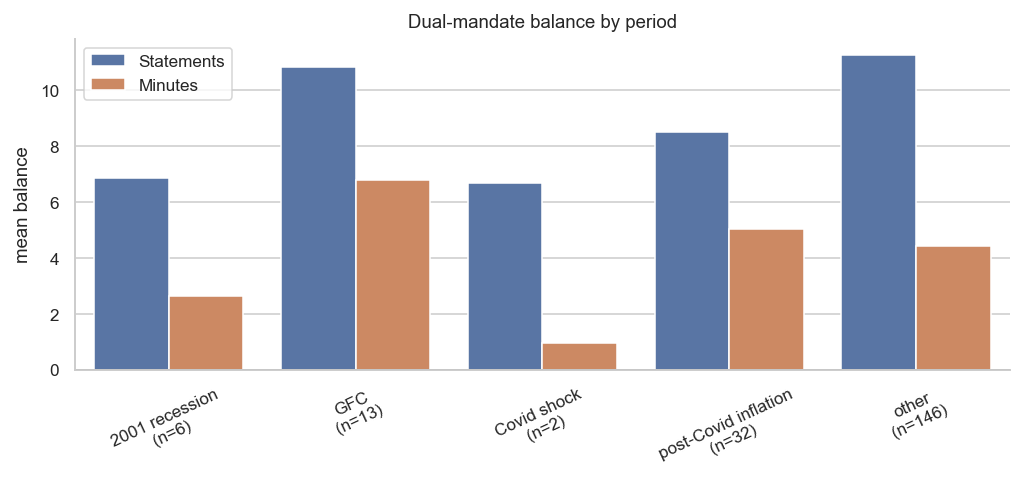

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
sns.barplot(
    data=balance_long,
    x="period",
    y="balance_per_1000",
    hue="document_type",
    errorbar=None,
    ax=ax,
)
period_counts = df.groupby("period", observed=True).size().reindex(PERIOD_ORDER)
period_labels = [f"{period}\n(n={int(period_counts.loc[period])})" for period in PERIOD_ORDER]
ax.set_xticks(range(len(period_labels)))
ax.set_xticklabels(period_labels)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Dual-mandate balance by period")
ax.set_xlabel("")
ax.set_ylabel("mean balance")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURES / "mandate_balance_by_period.png", bbox_inches="tight")

,date,rate_decision,statement_balance,minutes_balance,minutes_minus_statement_balance,label
5,2000-10-03,hold,31.41,9.55,-21.86,early 2000s
37,2004-09-21,hike,24.22,2.71,-21.51,2004-06 tightening
6,2000-11-15,hold,30.61,9.55,-21.06,early 2000s
47,2005-12-13,hike,33.61,13.10,-20.52,2004-06 tightening
7,2000-12-19,hold,23.81,4.09,-19.72,early 2000s
38,2004-11-10,hike,22.14,4.49,-17.65,2004-06 tightening
40,2005-02-02,hike,21.66,4.40,-17.26,2004-06 tightening
55,2006-12-12,hike,23.62,8.22,-15.40,2004-06 tightening
34,2004-05-04,hold,14.08,-1.26,-15.35,2004-06 tightening
44,2005-08-09,hike,27.97,12.88,-15.10,2004-06 tightening


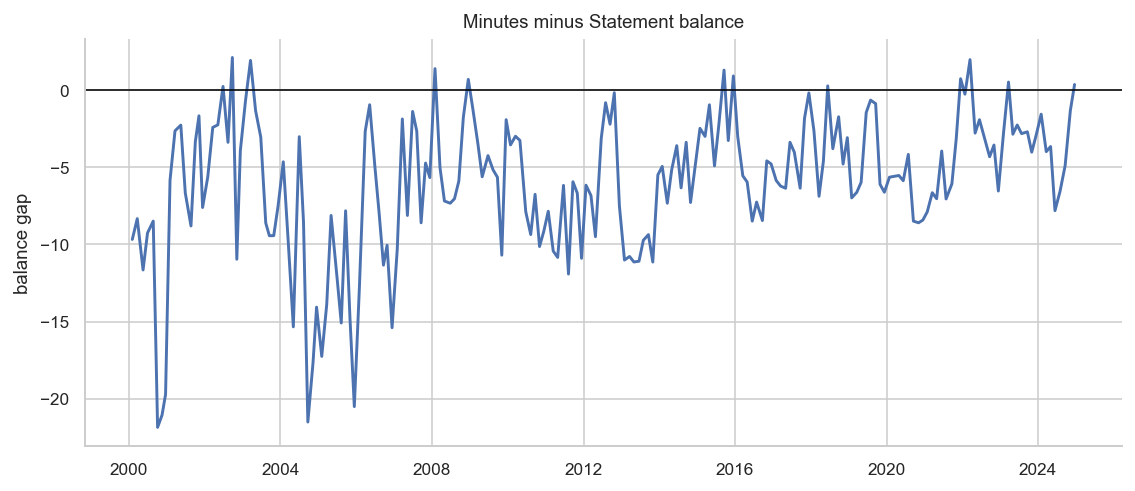

In [11]:
def gap_label(row):
    year = row["date"].year
    if 2004 <= year <= 2006:
        return "2004-06 tightening"
    if 2000 <= year <= 2001:
        return "early 2000s"
    if row["period"] != "other":
        return str(row["period"])
    return "other"


gap_data = df.assign(abs_gap=lambda x: x["minutes_minus_statement_balance"].abs())
gap_table = (
    gap_data
    .nlargest(10, "abs_gap")
    .assign(label=lambda x: x.apply(gap_label, axis=1))
    .loc[:, [
        "date", "rate_decision", "statement_balance", "minutes_balance",
        "minutes_minus_statement_balance", "label",
    ]]
    .round(2)
)

fig, ax = plt.subplots(figsize=(8.2, 3.6))
sns.lineplot(data=gap_data, x="date", y="minutes_minus_statement_balance", ax=ax, color="#4C72B0", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Minutes minus Statement balance")
ax.set_xlabel("")
ax.set_ylabel("balance gap")
fig.tight_layout()
fig.savefig(FIGURES / "statement_minutes_balance_gap.png", bbox_inches="tight")

gap_table

In [12]:
DECISION_SENTENCE_RE = re.compile(
    r"decided to|voted to|agreed to|target range|federal funds rate|discount rate|left unchanged|raise|lower|maintain",
    flags=re.IGNORECASE,
)
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def mask_rate_sentences(text):
    sentences = SENTENCE_SPLIT_RE.split("" if pd.isna(text) else str(text))
    kept = [sentence for sentence in sentences if not DECISION_SENTENCE_RE.search(sentence)]
    return clean_text(" ".join(kept))


df = df.assign(
    statement_masked_text=lambda x: x["statement_text"].map(mask_rate_sentences),
    minutes_masked_text=lambda x: x["minutes_text"].map(mask_rate_sentences),
)

FED_STOP_WORDS = sorted(ENGLISH_STOP_WORDS | {
    "accessibility", "action", "adriana", "alan", "april", "august", "barkin", "barr", "bernanke",
    "bies", "board", "button", "chair", "chairman", "committee", "cook", "date", "december",
    "discount", "donald", "download", "edward", "february", "ferguson", "federal", "fomc",
    "geithner", "gov", "governors", "gramlich", "greenspan", "home", "https", "immediate",
    "information", "janet", "jefferson", "jerome", "john", "jr", "july", "june", "kohn", "kugler",
    "lisa", "louis", "march", "mark", "mary", "may", "meeting", "menu", "messrs", "michael",
    "monetary", "mr", "ms", "november", "official", "olson", "open", "page", "philip", "policy",
    "powell", "press", "raphael", "release", "reserve", "roger", "search", "secure", "september",
    "submit", "subscribe", "susan", "timothy", "today", "toggle", "update", "website", "websites",
    "william", "yellen",
})

LABELS = ["cut", "hold", "hike"]
MODELS = {
    "majority": DummyClassifier(strategy="most_frequent"),
    "logreg": LogisticRegression(max_iter=2_000, class_weight="balanced"),
    "linear SVM": LinearSVC(class_weight="balanced", max_iter=5_000),
}


def fit_text_model(data, text_col, target_col, model_name, estimator, test_size=0.30):
    sample = (
        data.dropna(subset=[target_col])
        .loc[lambda x: x[target_col].isin(LABELS)]
        .sort_values("date")
        .reset_index(drop=True)
    )
    split = int(len(sample) * (1 - test_size))
    train = sample.iloc[:split]
    test = sample.iloc[split:]
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words=FED_STOP_WORDS,
            token_pattern=r"(?u)\b[a-z][a-z]+\b",
            ngram_range=(1, 2),
            min_df=2,
            max_features=5_000,
        )),
        ("model", clone(estimator)),
    ])
    pipe.fit(train[text_col], train[target_col])
    pred = pipe.predict(test[text_col])
    return {
        "target": target_col,
        "corpus": "Statements" if text_col.startswith("statement") else "Minutes",
        "text": "masked" if "masked" in text_col else "full",
        "model": model_name,
        "accuracy": accuracy_score(test[target_col], pred),
        "macro_f1": f1_score(test[target_col], pred, labels=LABELS, average="macro", zero_division=0),
    }

runs = []
for target_col in ["rate_decision", "next_rate_decision"]:
    for corpus in ["statement", "minutes"]:
        for text_col in [f"{corpus}_clean_text", f"{corpus}_masked_text"]:
            for model_name, estimator in MODELS.items():
                runs.append(fit_text_model(df, text_col, target_col, model_name, estimator))

model_results = pd.DataFrame(runs)
model_results.round(3)

,target,corpus,text,model,accuracy,macro_f1
0,rate_decision,Statements,full,majority,0.500,0.222
1,rate_decision,Statements,full,logreg,0.400,0.276
2,rate_decision,Statements,full,linear SVM,0.467,0.315
3,rate_decision,Statements,masked,majority,0.500,0.222
4,rate_decision,Statements,masked,logreg,0.400,0.248
5,rate_decision,Statements,masked,linear SVM,0.500,0.255
6,rate_decision,Minutes,full,majority,0.500,0.222
7,rate_decision,Minutes,full,logreg,0.533,0.394
8,rate_decision,Minutes,full,linear SVM,0.567,0.418
9,rate_decision,Minutes,masked,majority,0.500,0.222


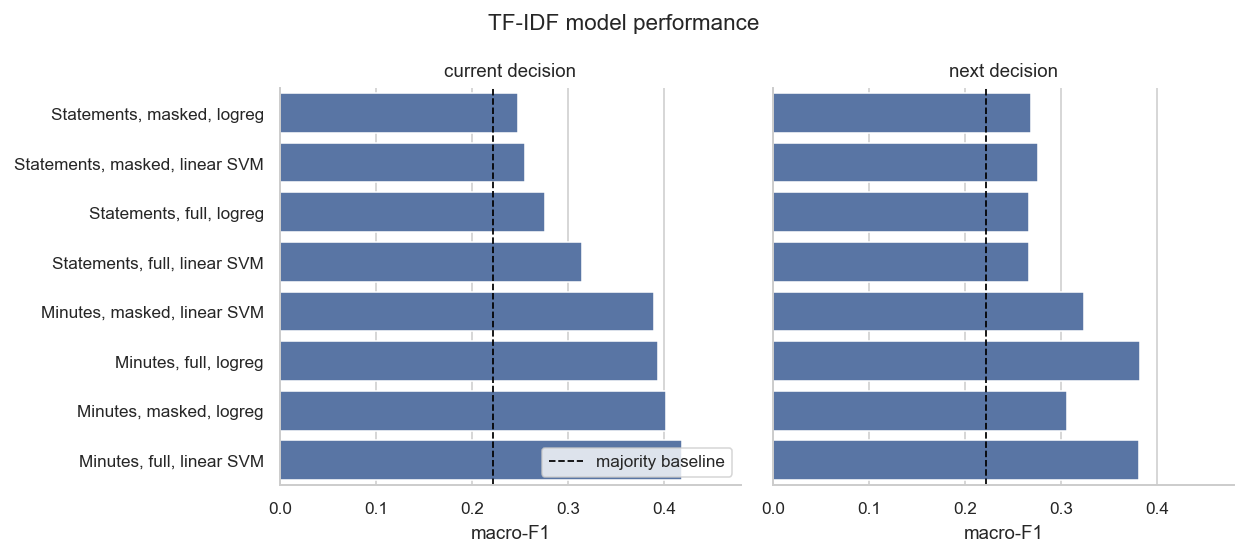

In [13]:
plot_results = model_results.loc[model_results["model"].ne("majority")].assign(
    target=lambda x: x["target"].map({"rate_decision": "current decision", "next_rate_decision": "next decision"}),
    setup=lambda x: x["corpus"] + ", " + x["text"] + ", " + x["model"],
)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.0), sharey=True)
for ax, target in zip(axes, ["current decision", "next decision"]):
    data = plot_results.loc[plot_results["target"].eq(target)].sort_values("macro_f1")
    sns.barplot(data=data, y="setup", x="macro_f1", ax=ax, color="#4C72B0")
    ax.axvline(2 / 9, color="black", linestyle="--", linewidth=0.9, label="majority baseline")
    ax.set_title(target)
    ax.set_xlabel("macro-F1")
    ax.set_ylabel("")
    ax.set_xlim(0, 0.48)
axes[0].legend(loc="lower right", frameon=True)
fig.suptitle("TF-IDF model performance")
fig.tight_layout()
fig.savefig(FIGURES / "model_macro_f1.png", bbox_inches="tight")

svd1_explained         0.051
svd2_explained         0.116
svd12_cum_explained    0.512
dtype: float64

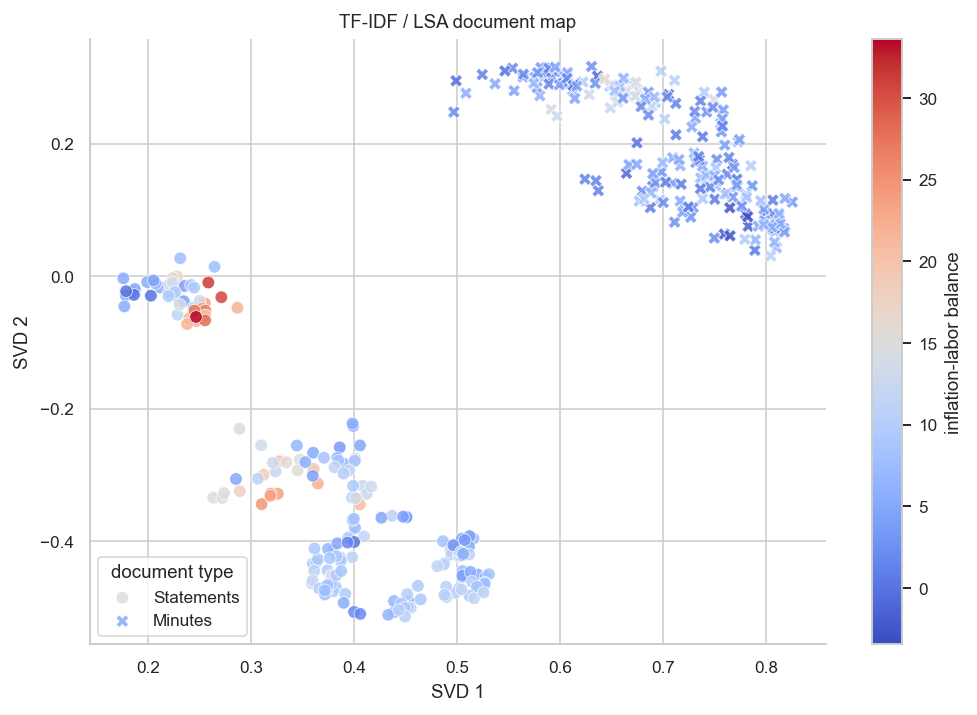

In [14]:
statement_docs = (
    df.loc[:, ["date", "year", "period", "rate_decision", "statement_clean_text", "statement_balance"]]
    .rename(columns={"statement_clean_text": "text", "statement_balance": "balance"})
    .assign(document_type="Statements")
)
minutes_docs = (
    df.loc[:, ["date", "year", "period", "rate_decision", "minutes_clean_text", "minutes_balance"]]
    .rename(columns={"minutes_clean_text": "text", "minutes_balance": "balance"})
    .assign(document_type="Minutes")
)
docs = pd.concat([statement_docs, minutes_docs], ignore_index=True)

vectorizer = TfidfVectorizer(
    stop_words=FED_STOP_WORDS,
    token_pattern=r"(?u)\b[a-z][a-z]+\b",
    ngram_range=(1, 2),
    min_df=2,
    max_features=8_000,
)
X = vectorizer.fit_transform(docs["text"])
svd = TruncatedSVD(n_components=20, random_state=42)
Z = svd.fit_transform(X)
Z_norm = normalize(Z[:, :12])

coords = docs.assign(svd_1=Z[:, 0], svd_2=Z[:, 1])

fig, ax = plt.subplots(figsize=(7.4, 5.2))
norm = plt.Normalize(coords["balance"].min(), coords["balance"].max())
cmap = plt.cm.coolwarm
for document_type, marker in [("Statements", "o"), ("Minutes", "X")]:
    plot_data = coords.loc[coords["document_type"].eq(document_type)]
    ax.scatter(
        plot_data["svd_1"],
        plot_data["svd_2"],
        c=plot_data["balance"],
        cmap=cmap,
        norm=norm,
        marker=marker,
        s=42,
        alpha=0.85,
        label=document_type,
        edgecolor="white",
        linewidth=0.4,
    )
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
colorbar.set_label("inflation-labor balance")
ax.set_title("TF-IDF / LSA document map")
ax.set_xlabel("SVD 1")
ax.set_ylabel("SVD 2")
ax.legend(title="document type", loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES / "lsa_document_map.png", bbox_inches="tight")

pd.Series({
    "svd1_explained": svd.explained_variance_ratio_[0],
    "svd2_explained": svd.explained_variance_ratio_[1],
    "svd12_cum_explained": svd.explained_variance_ratio_[:12].sum(),
}).round(3)

In [15]:
figure_files = sorted(path.name for path in FIGURES.glob("*.png"))
figure_files

['document_length_by_type.png',
 'embedding_balance_over_time.png',
 'embedding_dictionary_balance.png',
 'embedding_pca_map.png',
 'lsa_document_map.png',
 'mandate_balance_by_decision.png',
 'mandate_balance_by_period.png',
 'mandate_balance_over_time.png',
 'mandate_salience_over_time.png',
 'model_macro_f1.png',
 'sentence_topic_audit.png',
 'statement_minutes_balance_gap.png']